# Profile Q Estimation Example

This notebook demonstrates the profile-likelihood Q estimator on deterministic synthetic ring-down records. It is meant to explain not only how to read the output fields, but also why the profile estimate is different from taking an optimizer's fitted decay time and reporting $Q = \pi f \tau$.

A single-mode ring-down model can be written as

$$
x(t) = e^{-t/\tau}\left[a\cos(2\pi f t) + b\sin(2\pi f t)\right] + c + \epsilon(t),
$$

where $f$ is frequency, $\tau$ is the amplitude decay time, $a$, $b$, and $c$ are nuisance parameters, and $\epsilon(t)$ is measurement noise. The quality factor is related to the decay time by

$$
Q = \pi f \tau.
$$

The profile estimator treats $Q$ as an inference target. For each candidate $\tau$ on a log-spaced grid, it solves the linear least-squares problem for $a$, $b$, and $c$, then records the residual sum of squares. This is called variable projection: nonlinear parameters are scanned or optimized, while linear nuisance parameters are solved exactly at each point.

The main habit is to check `Q_profile_status` before quoting a finite Q value. A finite `Q_profile` is only reported when the profile curve closes on both sides of the optimum. If the data only support a lower or upper bound, the notebook shows how to read the corresponding one-sided limit.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ringdownanalysis import RingDownAnalyzer

In [2]:
def make_ringdown(*, fs, f0, tau, n_samples, noise, seed):
    t = np.arange(n_samples, dtype=float) / fs
    rng = np.random.default_rng(seed)
    x = np.exp(-t / tau) * np.cos(2.0 * np.pi * f0 * t)
    if noise > 0:
        x = x + noise * rng.normal(size=n_samples)
    return t, x


def summarize_q(result):
    if result["Q_profile_valid"]:
        return {
            "status": result["Q_profile_status"],
            "Q_profile": result["Q_profile"],
            "ci95": result["Q_profile_ci95"],
        }
    if result["Q_profile_status"] == "lower_limit":
        return {
            "status": result["Q_profile_status"],
            "Q_profile_lower_limit_95": result["Q_profile_lower_limit_95"],
        }
    return {
        "status": result["Q_profile_status"],
        "reasons": result["Q_profile_reasons"],
    }

## Finite Profile Q

This first record spans many decay times, so the envelope contains visible information about how quickly the oscillation decays. In this setting, small and large candidate values of $\tau$ both fit worse than the best value, and the profile has a well-defined minimum.

The code below compares the known synthetic value with the analyzer output. The raw NLS and DFT Q values are printed as diagnostics, but the inference-based result is `Q_profile`. The 95% interval is built from the profiled objective, not from the optimizer covariance matrix.

For a Gaussian-noise least-squares model, a one-parameter likelihood-ratio approximation says that the confidence set is the range where

$$
\Delta(\tau) = \mathrm{dof}\,\log\left(\frac{\mathrm{RSS}(\tau)}{\mathrm{RSS}_{\min}}\right)
$$

is below the 95% chi-square threshold for one parameter, approximately 3.84. Because $Q = \pi f\tau$ for fixed profiled frequency, the same interval maps directly from $\tau$ to $Q$.

In [3]:
fs = 200.0
f0 = 5.0
tau = 0.8
true_q = np.pi * f0 * tau

t, x = make_ringdown(fs=fs, f0=f0, tau=tau, n_samples=2000, noise=0.02, seed=1)
analyzer = RingDownAnalyzer()
finite = analyzer.analyze_array(t=t, data=x, tau_init=tau)

print(f"true Q: {true_q:.3e}")
print(summarize_q(finite))
print("raw NLS diagnostic:", finite["Q_nls_raw"], finite["Q_nls_status"])
print("raw DFT diagnostic:", finite["Q_dft_raw"], finite["Q_dft_status"])

true Q: 1.257e+01
{'status': 'valid', 'Q_profile': 12.545022447971027, 'ci95': (12.507891479125409, 12.662086958760055)}
raw NLS diagnostic: 12.545018970653686 valid
raw DFT diagnostic: 12.581179850559494 valid


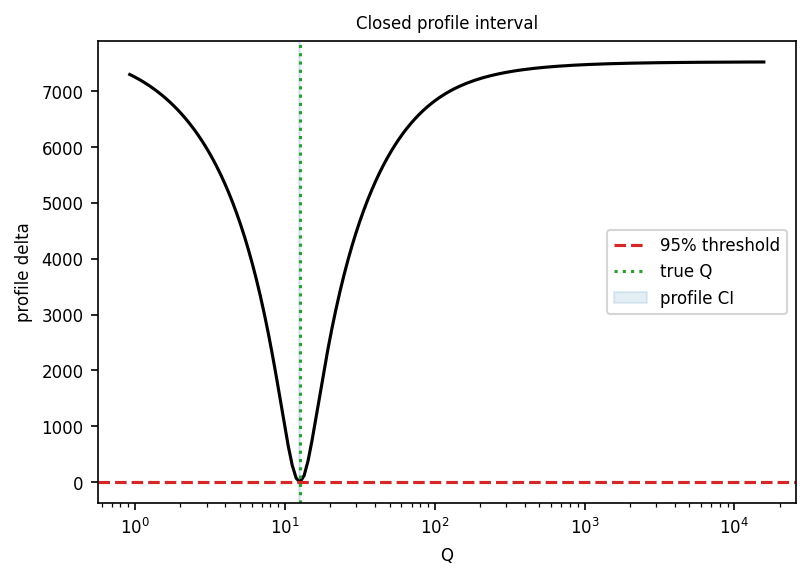

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(finite["Q_profile_q_grid"], finite["Q_profile_delta"])
ax.axhline(3.841458820694124, color="tab:red", linestyle="--", label="95% threshold")
ax.axvline(true_q, color="tab:green", linestyle=":", label="true Q")
if finite["Q_profile_ci95"] is not None:
    ax.axvspan(*finite["Q_profile_ci95"], color="tab:blue", alpha=0.12, label="profile CI")
ax.set_xscale("log")
ax.set_xlabel("Q")
ax.set_ylabel("profile delta")
ax.set_title("Closed profile interval")
ax.legend()
plt.show()

## Limit-Only Profile

High-Q data can look deceptively easy to fit: over a short record, a very slow exponential decay resembles an almost constant-amplitude sinusoid. Many large values of $\tau$ can explain the data nearly equally well, so an optimizer may still return a large finite decay time even though the experiment did not identify an upper endpoint for $Q$.

This second record covers only a small fraction of one decay time. The profile rises enough on the low-$Q$ side to rule out values below a threshold, but it stays too flat toward larger $Q$. That means the data support a one-sided lower limit rather than a finite estimate.

When `Q_profile_status` is `lower_limit`, the right interpretation is a statement such as $Q > Q_{\mathrm{lower},95}$ under the approximate profile-likelihood criterion. It is not appropriate to quote `tau_profile` or a raw NLS result as though the data had measured a finite Q.

In [5]:
t_hi, x_hi = make_ringdown(fs=fs, f0=f0, tau=10_000.0, n_samples=1000, noise=0.02, seed=3)
limit = analyzer.analyze_array(t=t_hi, data=x_hi, tau_init=10_000.0)

summarize_q(limit)

{'status': 'lower_limit', 'Q_profile_lower_limit_95': 9578.059142228889}

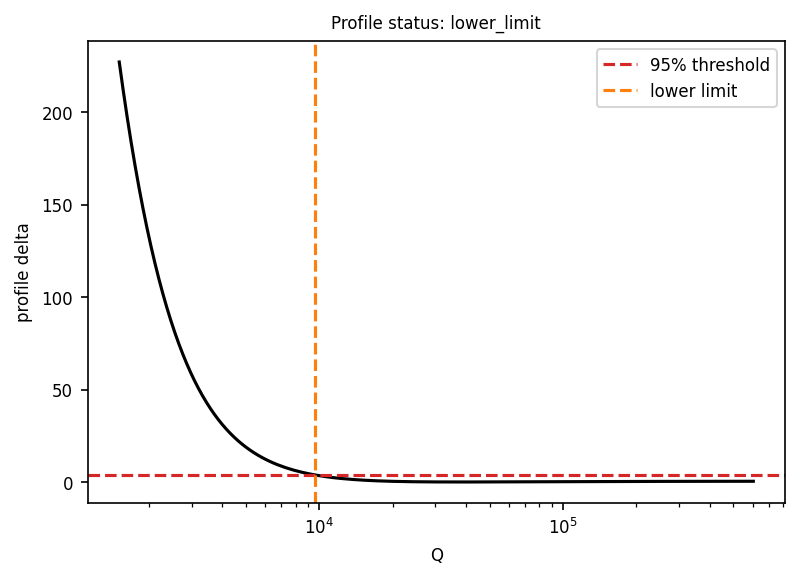

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(limit["Q_profile_q_grid"], limit["Q_profile_delta"])
ax.axhline(3.841458820694124, color="tab:red", linestyle="--", label="95% threshold")
if limit["Q_profile_lower_limit_95"] is not None:
    ax.axvline(
        limit["Q_profile_lower_limit_95"],
        color="tab:orange",
        linestyle="--",
        label="lower limit",
    )
ax.set_xscale("log")
ax.set_xlabel("Q")
ax.set_ylabel("profile delta")
ax.set_title(f"Profile status: {limit['Q_profile_status']}")
ax.legend()
plt.show()

## Sensitivity Records

A Q estimate should also be stable under reasonable choices of analysis window. If moving the start time, shortening the duration, or changing the crop policy changes the status from `valid` to `lower_limit` or `unbounded`, that is evidence that the record is not strongly identifying the decay time.

`q_sensitivity()` automates this repeated-window check and returns DataFrame-ready rows with the same profile-Q status and limit fields. In practice, this table is useful for separating two different questions:

- Statistical identifiability: does the profile close, and is there a finite interval for $Q$?
- Window robustness: do comparable windows return compatible finite intervals or compatible one-sided limits?

For publication or reporting, prefer records where `Q_profile_status == "valid"` and the finite intervals are stable across reasonable windows. For partial-decay records, report the one-sided profile limit instead of averaging raw NLS values.

In [7]:
records = analyzer.q_sensitivity(
    t,
    x,
    start_offsets=[0.0, 1.0],
    durations=[4.0],
    max_tau_multipliers=[3.0],
    tau_init=tau,
)

pd.DataFrame(records)[
    [
        "start_offset",
        "duration",
        "Q_profile",
        "Q_profile_status",
        "Q_profile_ci95",
        "Q_profile_lower_limit_95",
        "Q_nls_raw",
        "Q_nls_status",
    ]
]

,start_offset,duration,Q_profile,Q_profile_status,Q_profile_ci95,Q_profile_lower_limit_95,Q_nls_raw,Q_nls_status
0,0.0,4.0,12.551975,valid,"(12.466276155797301, 12.590208617265205)",None,12.551990,valid
1,1.0,4.0,12.531631,valid,"(11.997857247607653, 12.982828969260119)",None,12.531604,valid
